# Convert npz dataset to .txt separated files

## Utils function

In [2]:
import numpy as np
import os

# flat a multidimensional array coming from a .npz file
# considering S: samples, V: values (length_scale), T: time series (channels)
# transposition order tells how the flatenning would be done: (S,V,T), (2,0,1) -> (T,S,V) -> (T, S*V) -> (S*V, T)
def convert_npz_to_txt(dataset_path, out_dir, transposition_order, fmt="%.6f", ignore_files=None, force=False, verbose=True):
    # read .npz file
    npz = np.load(dataset_path)

    if force:
       print("You are forcingly overwriting files :)")
    elif os.path.exists(out_dir):
       print("The output folder already exists, are you sure you want to recreate it? In case set force to True...")
       return
    
    os.makedirs(out_dir, exist_ok=True)

    # iterate over the files 
    for file in npz.files:
      if ignore_files:
         if file in ignore_files:
            continue
           
      X = npz[file]

      # convert only files that match the number of transposition order dimensions
      if len(X.shape) != len(transposition_order):
         print(f"File {file} doesn't match the transposition order, {len(X.shape)} dimensions found instead of {len(transposition_order)}")
         continue
      
      # transpose and flatten
      X_flat = X.transpose(*transposition_order).reshape(X.shape[transposition_order[0]],-1).transpose()

      # create and save the file
      out_path = os.path.join(out_dir, f"{file}.txt")
      np.savetxt(out_path, X_flat, fmt=fmt)
      if verbose:
        print(f"{file}: from {X.shape} to {X_flat.shape}  ->  saved to {out_path}")

Normalization consists in normalizing the values in each channel, not sure whether it depends only on the channel or also inter-channel dependency for normalization. In any case, if you do normalize multiple patients data or a single one, the two plots for a single patient will change since the normalization is different.

In [2]:
import numpy as np
import os

# import data as the matrix with one single patient
from imputegap.recovery.manager import TimeSeries

# compare the two ways of loading data are identical
def two_ways_plots(file_name, npz_path, txt_path, sample_idx, transposition_order):
    npz = np.load(npz_path)

    X = npz[file_name]
    
    values_one_sample = X.shape[transposition_order[-1]]
    flatten_idx = sample_idx*values_one_sample

    # create compatible data: (T, S*V)
    X_compatible = X.transpose(*transposition_order).reshape(X.shape[transposition_order[0]],-1)

    assert X[sample_idx].transpose().shape == X_compatible[:, flatten_idx:flatten_idx+values_one_sample].shape, "Getting a single patient in the flatten doesn't work... Transposition order is correct?"
    assert np.all(X[sample_idx].transpose() == X_compatible[:, flatten_idx:flatten_idx+values_one_sample]), "The two do not correspond, maybe problems with the flatten idx"

    # import data as the matrix with all the patient values concatenated
    ts1 = TimeSeries()
    ts1.import_matrix(X_compatible)
    ts1.normalize(normalizer="z_score")
    # ts.print()
    # to select a specific patient, a slice the input data manually, there doesn't seem
    # to be a param to do so in plot.
    ts1.plot(input_data=ts1.data[:,flatten_idx:flatten_idx+values_one_sample], nbr_series=20, nbr_val=values_one_sample, save_path="./imputegap_assets")

    ts2 = TimeSeries()
    ts2.load_series(os.path.join(txt_path, f"{file_name}.txt"))
    print("dataset_loaded")
    ts2.normalize(normalizer="z_score")
    # ts2.print()
    # do the plot again for the patient with id 27
    ts2.plot(input_data=ts2.data[:,flatten_idx:flatten_idx+values_one_sample], nbr_series=20, nbr_val=values_one_sample, save_path="./imputegap_assets")

## Physionet

Physionet dataset has 35 channels (physiological parameters measure in the ICU), and 48 values (measurements taken for 2 days each hour).

In [3]:
dataset_path = 'external/physionet/physionet.npz'

dataset_name = 'physionet'
out_dir = os.path.join("external/datasets/", dataset_name)

# print(np.load(dataset_path)['x_train_full'].shape)

convert_npz_to_txt(dataset_path, out_dir, [2,0,1], fmt="%.7g")

The output folder already exists, are you sure you want to recreate it? In case set force to True...


In [ ]:
# verify that the conversion went well
two_ways_plots("x_train_full", 'external/physionet/physionet.npz', "external/datasets/physionet", 15, [2,0,1])

In [ ]:
# merge the different files into a single one, compatible with how 
# imputegap expects the datasets to be

full_files = ['x_train_full.txt', 'x_val_full.txt', 'x_test_full.txt']
miss_files = ['x_train_miss.txt', 'x_val_miss.txt', 'x_test_miss.txt']
m_files = ['m_train_miss.txt', 'm_val_miss.txt', 'm_test_miss.txt']


def merge_txt_files(out_dir, out_file_name, files_to_merge):
  with open(os.path.join(out_dir, out_file_name), 'w') as outfile:
      for fname in files_to_merge:
          with open(os.path.join(out_dir, fname), 'r') as infile:
              outfile.write(infile.read())

# merge_txt_files('external/datasets/physionet', 'x_full.txt', full_files)
# merge_txt_files('external/datasets/physionet', 'x_miss.txt', miss_files)
# merge_txt_files('external/datasets/physionet', 'm_miss.txt', m_files)

In [10]:
x_miss = np.loadtxt('external/datasets/physionet/x_miss.txt')
m_miss = np.loadtxt('external/datasets/physionet/m_miss.txt')

In [ ]:
x_nan = x_miss.copy()
x_nan[m_miss==1] = np.nan
np.savetxt('external/datasets/physionet/x_miss_nan.txt', x_nan)

In [16]:
np.loadtxt('external/datasets/physionet/x_miss_nan.txt').shape

(575376, 35)

## HMNIST

HMNIST values are float32, use fmt="%.7g", 7 significant digits.

I tried with text files, but probably with two large files the code crashes. I will use import matrix instead.

In [ ]:
dataset_path = 'external/hmnist/hmnist_mnar.npz'

dataset_name = 'hmnist'
out_dir = os.path.join("external/datasets/", dataset_name)

# print(np.load(dataset_path)['x_train_full'].shape)

# convert_npz_to_txt(dataset_path, out_dir, [2,0,1], fmt="%.7g")

x_train_full: from (60000, 10, 784) to (600000, 784)  ->  saved to external/datasets/hmnist/x_train_full.txt
x_train_miss: from (60000, 10, 784) to (600000, 784)  ->  saved to external/datasets/hmnist/x_train_miss.txt
m_train_miss: from (60000, 10, 784) to (600000, 784)  ->  saved to external/datasets/hmnist/m_train_miss.txt
File y_train doesn't match the transposition order, 1 dimensions found instead of 3
x_test_full: from (10000, 10, 784) to (100000, 784)  ->  saved to external/datasets/hmnist/x_test_full.txt
x_test_miss: from (10000, 10, 784) to (100000, 784)  ->  saved to external/datasets/hmnist/x_test_miss.txt
m_test_miss: from (10000, 10, 784) to (100000, 784)  ->  saved to external/datasets/hmnist/m_test_miss.txt
File y_test doesn't match the transposition order, 1 dimensions found instead of 3


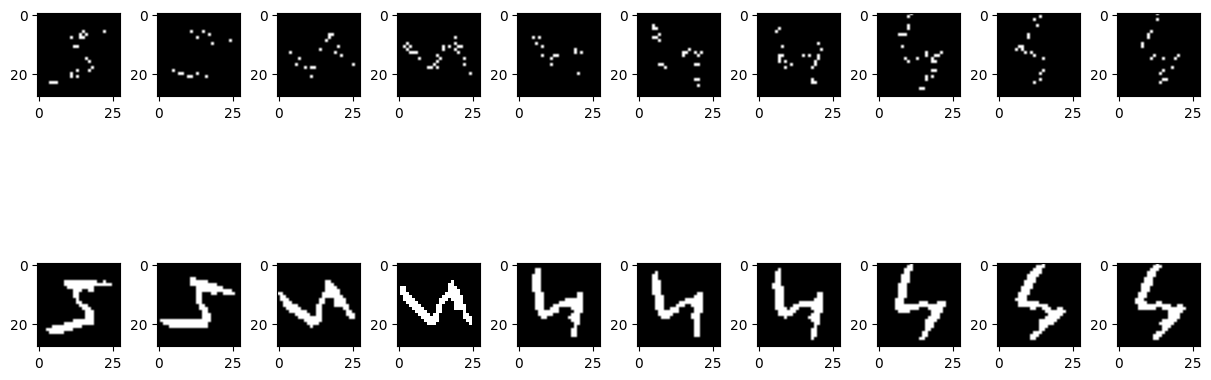

In [3]:
import matplotlib.pyplot as plt
import numpy as np

npz_hmnist = np.load('external/hmnist/hmnist_mnar.npz')
x_train_full_hmnist = npz_hmnist['x_train_full']
x_train_miss_hmnist = npz_hmnist['x_train_miss']
fig, axes = plt.subplots(2,x_train_full_hmnist.shape[1], layout='constrained', figsize=(12, 5))
for i in range(x_train_full_hmnist.shape[1]):
    axes[0,i].imshow(x_train_miss_hmnist[0][i].reshape(28, 28, 1), cmap='gray')
for i in range(x_train_full_hmnist.shape[1]):
    axes[1,i].imshow(x_train_full_hmnist[0][i].reshape(28, 28, 1), cmap='gray')

## SPRITES

Same as HMNIST, values are float32, use fmt="%.7g", 7 significant digits.

I tried with text files, but probably with too large files the code to load_series crashes. I will use import matrix instead.

In [ ]:
dataset_path = 'external/sprites/sprites.npz'

dataset_name = 'sprites'
out_dir = os.path.join("external/datasets/", dataset_name)

# print(np.load(dataset_path)['x_train_full'].shape)

# convert_npz_to_txt(dataset_path, out_dir, [2,0,1], fmt="%.7g")

x_train_full: from (9000, 8, 12288) to (72000, 12288)  ->  saved to external/datasets/sprites/x_train_full.txt
x_train_miss: from (9000, 8, 12288) to (72000, 12288)  ->  saved to external/datasets/sprites/x_train_miss.txt
m_train_miss: from (9000, 8, 12288) to (72000, 12288)  ->  saved to external/datasets/sprites/m_train_miss.txt
x_test_full: from (2664, 8, 12288) to (21312, 12288)  ->  saved to external/datasets/sprites/x_test_full.txt
x_test_miss: from (2664, 8, 12288) to (21312, 12288)  ->  saved to external/datasets/sprites/x_test_miss.txt
m_test_miss: from (2664, 8, 12288) to (21312, 12288)  ->  saved to external/datasets/sprites/m_test_miss.txt
